In [ ]:
import os
# Uninstall conflicting packages
!pip uninstall -y bitsandbytes cuda-toolkit torch torchvision torchao transformers accelerate diffusers peft datasets huggingface_hub xformers

# Reinstall core dependencies with versions compatible with Torch 2.3.1 and Python 3.12
!pip install -U \
    peft==0.11.1 \
    diffusers==0.28.0 \
    accelerate==0.28.0 \
    torchao==0.4.0 \
    huggingface_hub==0.20.2 \
    datasets \
    transformers \
    torch==2.3.1 \
    torchvision==0.18.1 \
    bitsandbytes \
    safetensors

# Install xformers compatible with torch 2.3.1
!pip install xformers==0.0.27 --index-url https://download.pytorch.org/whl/cu121

os.kill(os.getpid(), 9)

Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2
Found existing installation: torch 2.3.1
Uninstalling torch-2.3.1:
  Successfully uninstalled torch-2.3.1
Found existing installation: torchvision 0.18.1
Uninstalling torchvision-0.18.1:
  Successfully uninstalled torchvision-0.18.1
Found existing installation: torchao 0.4.0
Uninstalling torchao-0.4.0:
  Successfully uninstalled torchao-0.4.0
Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
Found existing installation: accelerate 0.28.0
Uninstalling accelerate-0.28.0:
  Successfully uninstalled accelerate-0.28.0
Found existing installation: diffusers 0.28.0
Uninstalling diffusers-0.28.0:
  Successfully uninstalled diffusers-0.28.0
Found existing installation: peft 0.11.1
Uninstalling peft-0.11.1:
  Successfully uninstalled peft-0.11.1
Found existing installation: datasets 2.18.0

In [2]:
from huggingface_hub import notebook_login
notebook_login()

Generating train split:   0%|          | 0/2202 [00:00<?, ? examples/s]

Total dataset size: 2202 examples


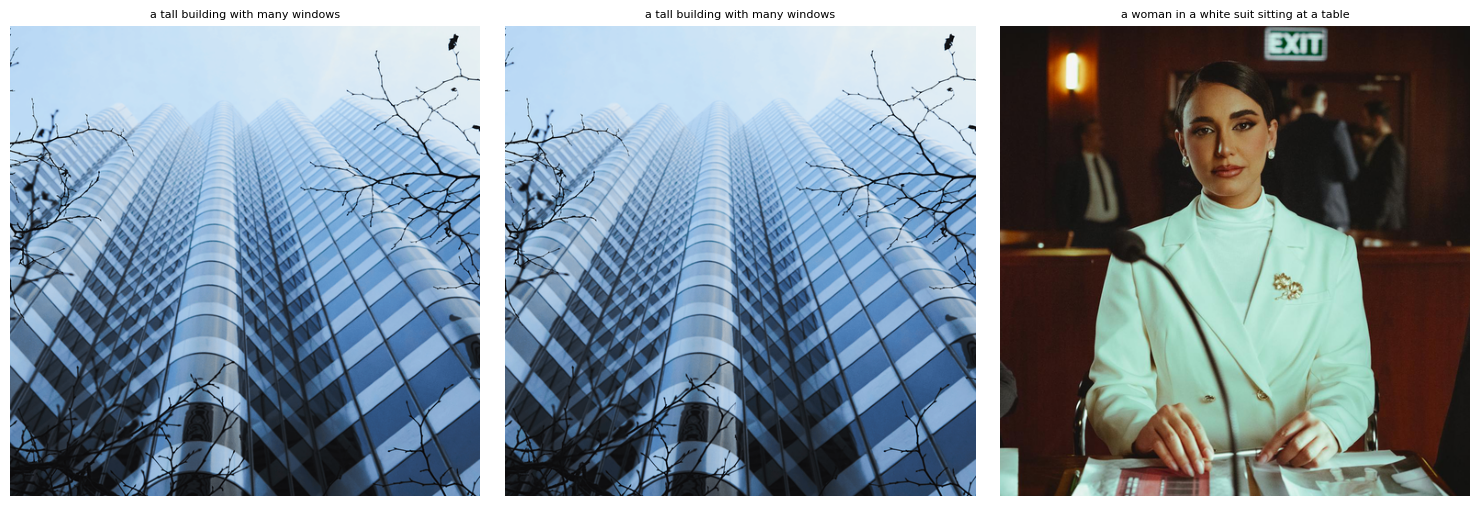

In [3]:
from datasets import load_dataset
import matplotlib.pyplot as plt
from PIL import Image

dataset_name = "Dhruvi512/office-workspace-dataset"
dataset = load_dataset(dataset_name)

# Access the 'train' split, assuming it's available
# You might need to adjust this if your dataset has a different split name (e.g., 'data')
if 'train' in dataset:
    data_split = dataset['train']
elif 'data' in dataset:
    data_split = dataset['data']
else:
    # Fallback to the first available split if names are unexpected
    first_split_name = list(dataset.keys())[0]
    data_split = dataset[first_split_name]
    print(f"Warning: 'train' or 'data' split not found. Using '{first_split_name}' split.")


print(f"Total dataset size: {len(data_split)} examples")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(min(3, len(data_split))):
    example = data_split[i]
    image = example['image']
    caption = example['text']

    # Ensure image is a PIL Image object
    if not isinstance(image, Image.Image):
        image = Image.open(image) # Assuming image column contains paths if not direct PIL images

    axes[i].imshow(image)
    axes[i].set_title(caption, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from accelerate.utils import set_seed
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel, DiffusionPipeline
from diffusers.optimization import get_scheduler
from transformers import AutoTokenizer, CLIPTextModel
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
from torchvision import transforms
from tqdm.auto import tqdm
import os
import numpy as np
import gc

# --- Configuration --- #
MODEL_ID = "runwayml/stable-diffusion-v1-5"
DATASET_NAME = "Dhruvi512/office-workspace-dataset"
OUTPUT_DIR = "/content/officeworkspace-lora/"

# LoRA parameters
LORA_RANK = 4
LORA_ALPHA = 32
TARGET_MODULES = ["to_q", "to_v", "to_k", "to_out.0"]

# Training parameters
TRAIN_STEPS = 1500 # Further increased for better quality, allowing more learning
LEARNING_RATE = 1e-4
BATCH_SIZE = 1 # Keep batch size as 1 for processing each image sequentially in memory
IMAGE_SIZE = 384 # Compromise between 256 and 512 for memory and quality
MIXED_PRECISION = "fp16"
GRADIENT_ACCUMULATION_STEPS = 4 # Increased for effective batch size of BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS
LR_SCHEDULER_TYPE = "constant"
LR_WARMUP_STEPS = 0
USE_8BIT_ADAM = True # Use 8-bit Adam for lower VRAM usage

# Set random seed
set_seed(42)

# Clear memory (initial cleanup)
gc.collect()
torch.cuda.empty_cache()

# --- Accelerator Setup --- #
accelerator = Accelerator(
    mixed_precision=MIXED_PRECISION,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
)

# --- Load Model Components --- #
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder", torch_dtype=torch.float32)
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", torch_dtype=torch.float32)
unet = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet", torch_dtype=torch.float32)

vae.requires_grad_(False)
text_encoder.requires_grad_(False)

# Memory optimizations
unet.enable_gradient_checkpointing()
unet.enable_xformers_memory_efficient_attention()

# --- Prepare LoRA for UNet --- #
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    init_lora_weights="gaussian",
    target_modules=TARGET_MODULES,
)
unet = get_peft_model(unet, lora_config)

# --- Dataset and DataLoader --- #
dataset = load_dataset(DATASET_NAME)['train']

def preprocess_data(example):
    image = example["image"].convert("RGB")
    image_transforms = transforms.Compose([
        transforms.Resize(IMAGE_SIZE, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])
    pixel_values = image_transforms(image)

    input_ids = tokenizer(
        example["text"],
        max_length=tokenizer.model_max_length,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).input_ids[0]

    return {"pixel_values": pixel_values, "input_ids": input_ids}

with accelerator.main_process_first():
    processed_dataset = dataset.map(
        preprocess_data,
        batched=False,
        remove_columns=dataset.column_names,
        desc="Preprocessing dataset",
    )

def collate_fn(examples):
    def ensure_tensor(val):
        if isinstance(val, list):
            return torch.tensor(val)
        return val

    pixel_values = torch.stack([ensure_tensor(example["pixel_values"]) for example in examples])
    pixel_values = pixel_values.to(memory_format=torch.contiguous_format).float()
    input_ids = torch.stack([ensure_tensor(example["input_ids"]) for example in examples])
    return {"pixel_values": pixel_values, "input_ids": input_ids}

train_dataloader = torch.utils.data.DataLoader(
    processed_dataset,
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=BATCH_SIZE,
)

# --- Optimizer and Scheduler --- #
if USE_8BIT_ADAM:
    import bitsandbytes as bnb
    optimizer_cls = bnb.optim.AdamW8bit
else:
    optimizer_cls = torch.optim.AdamW

optimizer = optimizer_cls(unet.parameters(), lr=LEARNING_RATE)
lr_scheduler = get_scheduler(
    LR_SCHEDULER_TYPE,
    optimizer=optimizer,
    num_warmup_steps=LR_WARMUP_STEPS * GRADIENT_ACCUMULATION_STEPS,
    num_training_steps=TRAIN_STEPS * GRADIENT_ACCUMULATION_STEPS,
)

unet, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
    unet, optimizer, train_dataloader, lr_scheduler
)

weight_dtype = torch.float16 if accelerator.mixed_precision == "fp16" else torch.float32
vae.to(accelerator.device, dtype=weight_dtype)
text_encoder.to(accelerator.device, dtype=weight_dtype)

# --- Training Loop --- #
print("\n***** Running Training *****")
global_step = 0
unet.train()

progress_bar = tqdm(range(TRAIN_STEPS), disable=not accelerator.is_local_main_process)
progress_bar.set_description("Steps")

while global_step < TRAIN_STEPS:
    for batch in train_dataloader:
        if global_step >= TRAIN_STEPS:
            break

        with accelerator.accumulate(unet):
            # Ensure inputs are in the correct dtype for VAE/Text Encoder
            pixel_values = batch["pixel_values"].to(weight_dtype)
            input_ids = batch["input_ids"]

            with torch.no_grad(): # VAE and Text Encoder are frozen, so no_grad is appropriate
                latents = vae.encode(pixel_values).latent_dist.sample()
                latents = latents * vae.config.scaling_factor

                noise = torch.randn_like(latents)
                bsz = latents.shape[0]
                timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=latents.device).long()
                noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

                encoder_hidden_states = text_encoder(input_ids)[0]

            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

            loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")
            accelerator.backward(loss)

            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

            # More aggressive memory cleanup for GPU after each optimization step
            if accelerator.is_main_process:
                torch.cuda.empty_cache()
                gc.collect()


        if accelerator.sync_gradients:
            progress_bar.update(1)
            progress_bar.set_postfix(loss=f"{loss.item():.4f}") # Display current loss
            global_step += 1

        if global_step >= TRAIN_STEPS:
            break

if accelerator.is_main_process:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    unwrapped_model = accelerator.unwrap_model(unet)
    # Save only the LoRA weights, not the entire UNet (which would be huge)
    unwrapped_model.save_pretrained(OUTPUT_DIR)
    print(f"LoRA weights saved to {OUTPUT_DIR}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recomm

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

In [ ]:
from huggingface_hub import HfApi, create_repo, upload_folder

# Configuration
repo_id = "Dhruvi512/officeworkspace-lora"
local_folder = "/content/officeworkspace-lora/"

try:
    # Create the private repository
    create_repo(repo_id=repo_id, private=True, exist_ok=True)

    # Upload the folder
    repo_url = upload_folder(
        folder_path=local_folder,
        repo_id=repo_id,
        repo_type="model"
    )

    print(f"Upload successful! You can find your model here: {repo_url}")
except Exception as e:
    print(f"An error occurred during upload: {e}")

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
from peft import PeftModel
import matplotlib.pyplot as plt

# Configuration
model_id = "runwayml/stable-diffusion-v1-5"
lora_weights_path = "/content/officeworkspace-lora/"
prompt = "officeworkspace style, a modern laptop on a wooden desk next to a coffee cup, highly detailed"

# 1. Load the base pipeline
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to("cuda")

# 2. Load the LoRA weights specifically as a PEFT model over the UNet
# This handles the 'adapter_model.safetensors' file correctly
print("Loading LoRA weights...")
pipe.unet = PeftModel.from_pretrained(pipe.unet, lora_weights_path)

# Generate image
print(f"Generating image for prompt: {prompt}")
with torch.inference_mode():
    # Note: When using PeftModel, the pipeline works normally
    image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

# Display the result
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis("off")
plt.title(prompt)
plt.show()